In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.sample(5)

,cgpa,placement_exam_marks,placed
779,6.39,32.0,0
458,7.13,47.0,0
694,7.12,51.0,0
256,7.37,48.0,1
328,7.40,28.0,1


In [4]:
df.shape

(1000, 3)

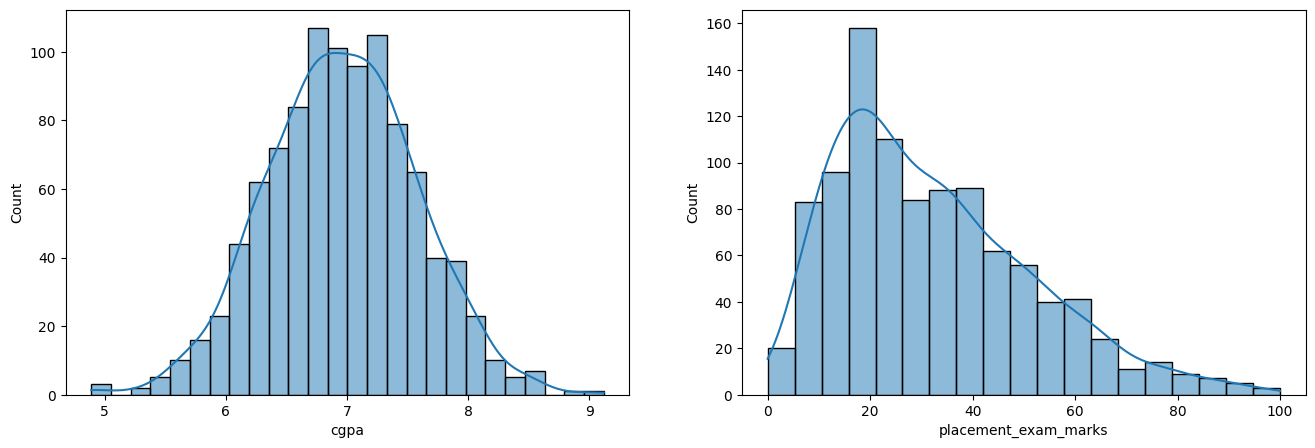

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.show()

## Observation:
Upon observing the data, it becomes evident that the **cgpa** column follows a normal distribution, while the **placement_exam_marks** column exhibits right-skewness. Since z-score approach is applicable only to the normal distribution, so we apply it to **cgpa** column.

In [6]:
print('The min value in CGPA column', df['cgpa'].min())
print('The max value in CGPA column', df['cgpa'].max())
print('The mean value in CGPA column', df['cgpa'].mean())
print('The std dev in CGPA column', df['cgpa'].std())

The min value in CGPA column 4.89
The max value in CGPA column 9.12
The mean value in CGPA column 6.96124
The std dev in CGPA column 0.6158978751323896


In [7]:
# Calculate the Z-score

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [8]:
print(df.sample(10))

     cgpa  placement_exam_marks  placed  cgpa_zscore
762  6.79                  14.0       1    -0.278033
12   6.58                  16.0       1    -0.618999
197  6.75                  27.0       0    -0.342979
385  7.33                  21.0       0     0.598736
398  7.55                  48.0       0     0.955938
817  7.84                  26.0       0     1.426795
868  7.33                  36.0       0     0.598736
814  7.78                  17.0       1     1.329376
764  6.47                  70.0       1    -0.797600
467  6.65                   7.0       0    -0.505344


In [9]:
# Any value that is < -3 or > +3 is an outlier.
mask = (df['cgpa_zscore'] < -3) | (df['cgpa_zscore'] > +3)

outliers = df[mask]

print(outliers)

     cgpa  placement_exam_marks  placed  cgpa_zscore
485  4.92                  44.0       1    -3.314251
995  8.87                  44.0       1     3.099150
996  9.12                  65.0       1     3.505062
997  4.89                  34.0       0    -3.362960
999  4.90                  10.0       1    -3.346724


We see that there are 3 rows with values below the lower boundary(-3) and 2 rows with values above the highest boundary(+3) with total=5 rows

To address the outliers, we will employ the trimming approach and eliminate all rows with outliers in our dataset.

# Approach 1) Trimming using z-score

In [16]:
# Trimming 

df_trim = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [17]:
outliers = df_trim[(df_trim['cgpa_zscore'] > 3) | (df_trim['cgpa_zscore'] < -3)]
print(outliers)

Empty DataFrame
Columns: [cgpa, placement_exam_marks, placed, cgpa_zscore]
Index: []


In [18]:
print(f"shape:{df_trim.shape}") # rows,columns
print("###############")
print(f"df_trim:\n{df_trim}")

shape:(995, 4)
###############
df_trim:
     cgpa  placement_exam_marks  placed  cgpa_zscore
0    7.19                  26.0       1     0.371425
1    7.46                  38.0       1     0.809810
2    7.54                  40.0       1     0.939701
3    6.42                   8.0       1    -0.878782
4    7.23                  17.0       0     0.436371
..    ...                   ...     ...          ...
991  7.04                  57.0       0     0.127878
992  6.26                  12.0       0    -1.138565
993  6.73                  21.0       1    -0.375452
994  6.48                  63.0       0    -0.781363
998  8.62                  46.0       1     2.693239

[995 rows x 4 columns]


# Approach 2) Capping

Let’s apply the capping method to address the outliers in the dataset.

To handle outliers using the capping method, we will **replace** all values above the upper limit with the upper limit value and all values below the lower limit with the lower limit value.

In [23]:
upper_limit = +3
lowest_limit = -3

df_cap = df.copy()
df_cap['cgpa_zscore'] = np.where(
    df_cap['cgpa_zscore'] > upper_limit,
    upper_limit,
    np.where(
        df_cap['cgpa_zscore'] < lowest_limit,
        lowest_limit,
        df_cap['cgpa_zscore']
    )
)

In [24]:
outliers = df_cap[(df_cap['cgpa_zscore'] > 3) | (df_cap['cgpa_zscore'] < -3)]
print(outliers)

Empty DataFrame
Columns: [cgpa, placement_exam_marks, placed, cgpa_zscore]
Index: []


In [25]:
print(df_cap.shape)

(1000, 4)


In [26]:
print('The min value in CGPA column', df_cap['cgpa'].min())
print('The max value in CGPA column', df_cap['cgpa'].max())

The min value in CGPA column 4.89
The max value in CGPA column 9.12


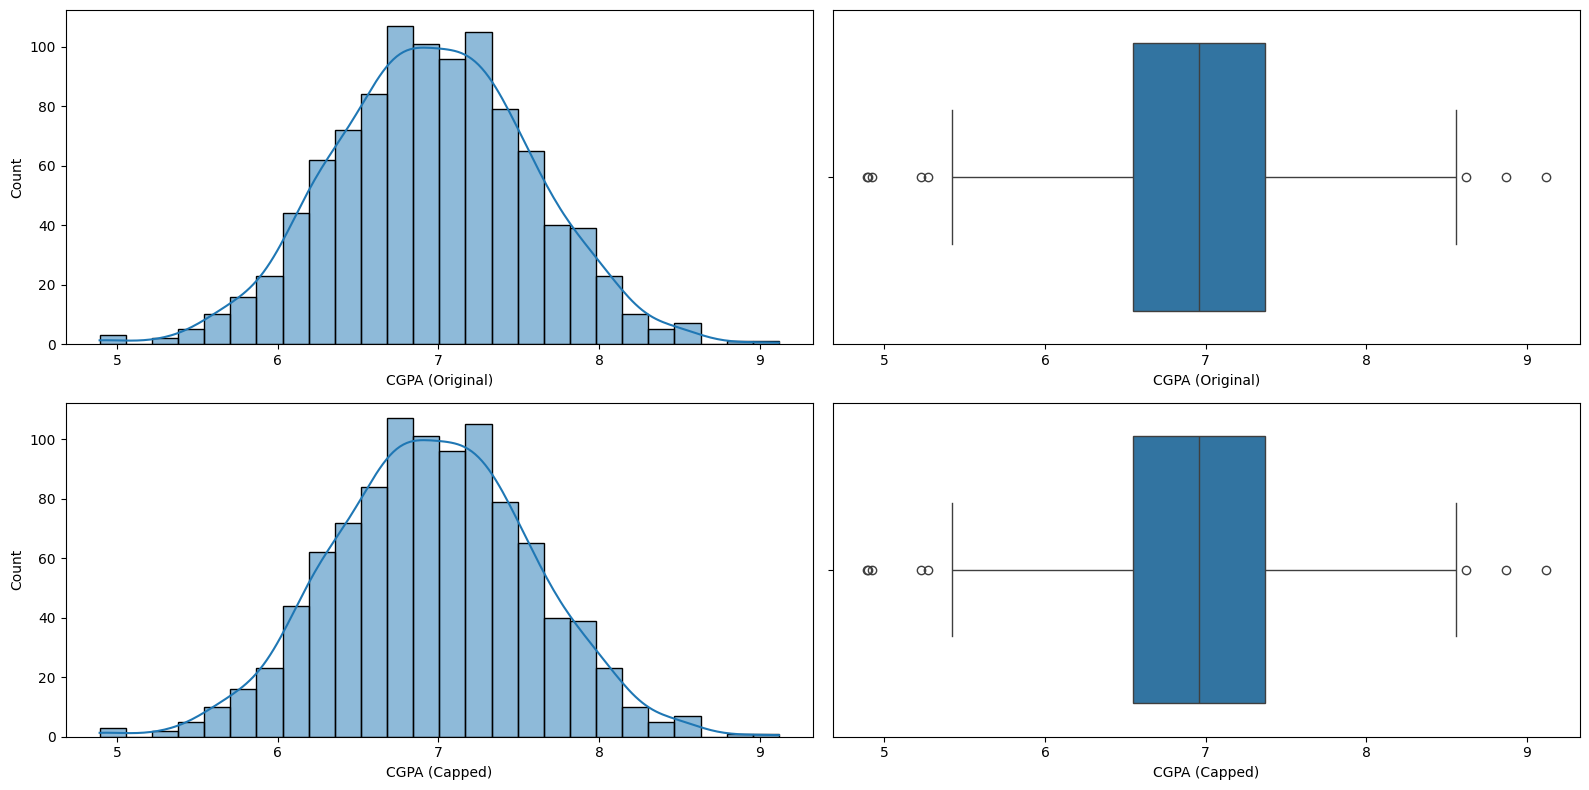

In [27]:
plt.figure(figsize=(16, 8))

# First subplot
plt.subplot(2, 2, 1)
sns.histplot(df['cgpa'], kde=True)  # Use histplot instead of distplot
plt.xlabel("CGPA (Original)")

# Second subplot
plt.subplot(2, 2, 2)
sns.boxplot(x=df['cgpa'])
plt.xlabel("CGPA (Original)")

# Third subplot
plt.subplot(2, 2, 3)
sns.histplot(df_cap['cgpa'], kde=True)  # Use histplot instead of distplot
plt.xlabel("CGPA (Capped)")

# Fourth subplot
plt.subplot(2, 2, 4)
sns.boxplot(x=df_cap['cgpa'])
plt.xlabel("CGPA (Capped)")

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

### Great. Plot is relatively same

# STOP

# OPTIONAL: Another method without z-score

In [28]:
# finding boundary value

upper_limit  = df['cgpa'].mean() + 3*df['cgpa'].std()
lowest_limit = df['cgpa'].mean() - 3*df['cgpa'].std()
print('highest boundary :',upper_limit)
print('lowest boundary :', lowest_limit)

highest boundary : 8.808933625397168
lowest boundary : 5.113546374602832


In [29]:
# Finding the outliers for cgpa

outliers = df[(df['cgpa'] > upper_limit) | (df['cgpa'] <lowest_limit)]
print(outliers)


     cgpa  placement_exam_marks  placed  cgpa_zscore
485  4.92                  44.0       1    -3.314251
995  8.87                  44.0       1     3.099150
996  9.12                  65.0       1     3.505062
997  4.89                  34.0       0    -3.362960
999  4.90                  10.0       1    -3.346724


We see that there are 3 rows with values below the lower boundary and 2 rows with values above the highest boundary with total=5 rows

To address the outliers, we will employ the trimming approach and eliminate all rows with outliers in our dataset.

# Approach: Trimming without using z-score

In [32]:
df_trim = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]

In [34]:
# Finding the outliers for cgpa

outliers = df_trim[(df_trim['cgpa'] > upper_limit) | (df_trim['cgpa'] <lowest_limit)]
print(outliers)


Empty DataFrame
Columns: [cgpa, placement_exam_marks, placed, cgpa_zscore]
Index: []


In [35]:
print(f"shape:{df_trim.shape}") # rows,columns
print("###############")
print(f"new_df:\n{df_trim}")

shape:(995, 4)
###############
new_df:
     cgpa  placement_exam_marks  placed  cgpa_zscore
0    7.19                  26.0       1     0.371425
1    7.46                  38.0       1     0.809810
2    7.54                  40.0       1     0.939701
3    6.42                   8.0       1    -0.878782
4    7.23                  17.0       0     0.436371
..    ...                   ...     ...          ...
991  7.04                  57.0       0     0.127878
992  6.26                  12.0       0    -1.138565
993  6.73                  21.0       1    -0.375452
994  6.48                  63.0       0    -0.781363
998  8.62                  46.0       1     2.693239

[995 rows x 4 columns]


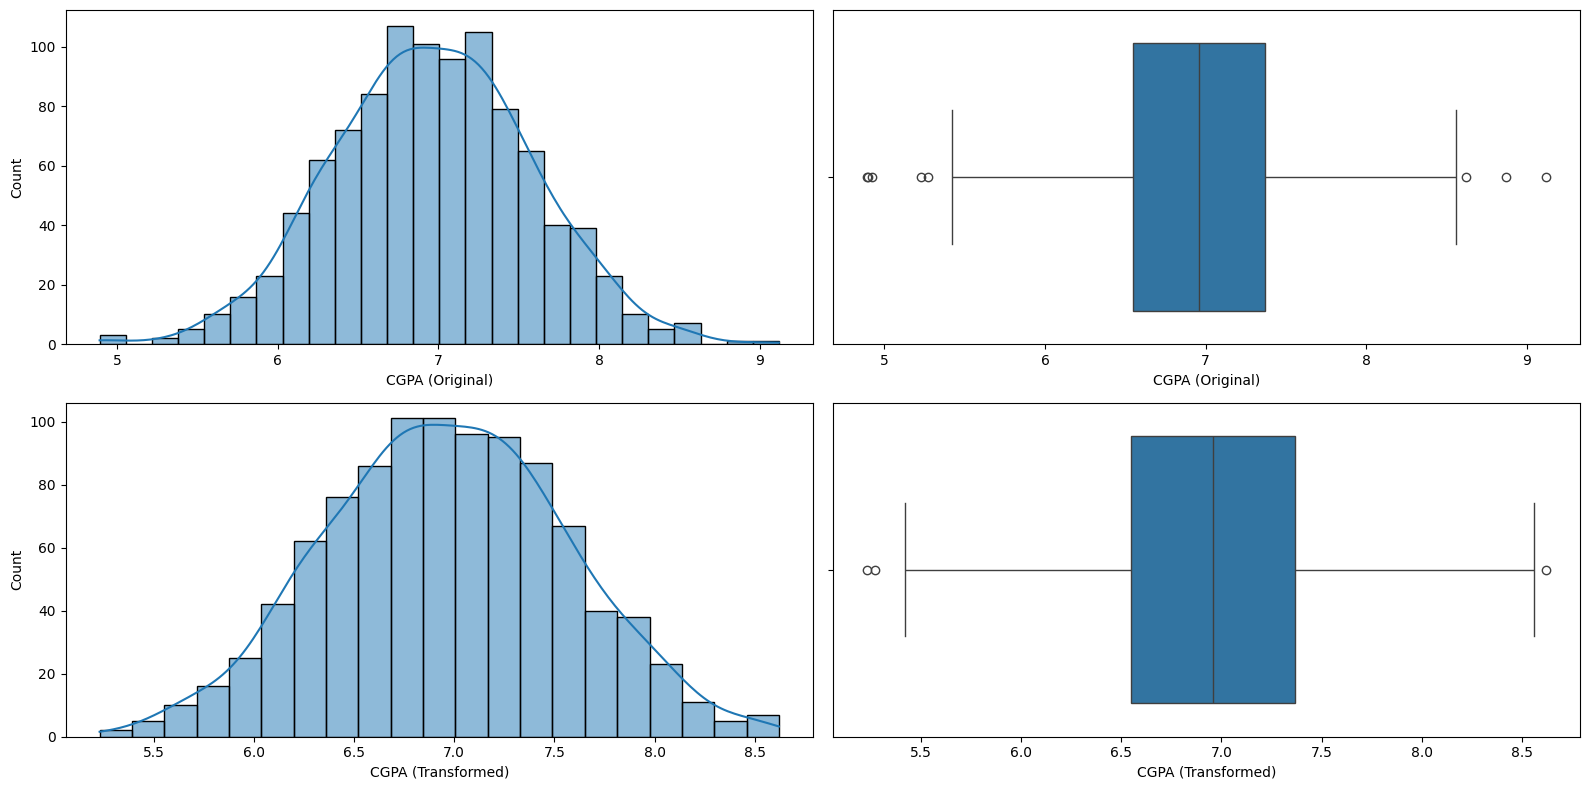

In [36]:
plt.figure(figsize=(16, 8))

# First subplot
plt.subplot(2, 2, 1)
sns.histplot(df['cgpa'], kde=True)  
plt.xlabel("CGPA (Original)")  

# Second subplot
plt.subplot(2, 2, 2)
sns.boxplot(x=df['cgpa'])
plt.xlabel("CGPA (Original)")

# Third subplot
plt.subplot(2, 2, 3)
sns.histplot(df_trim['cgpa'], kde=True)
plt.xlabel("CGPA (Transformed)")

# Fourth subplot
plt.subplot(2, 2, 4)
sns.boxplot(x=df_trim['cgpa'])
plt.xlabel("CGPA (Transformed)")

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

### Great. Plot is relatively same